In [1]:
from gc import collect

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pyparsing import col

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_recall_curve, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [2]:
df = pd.read_parquet("../data/processed/UCI_Credit_Card.parquet")

# Gộp các giá trị hiếm
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

# Tạo các đặc trưng mới (Feature Engineering)

In [3]:
# 1. Các biến về số lần chậm thanh toán
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['late_count'] = (df[pay_cols] > 0).sum(axis=1)               # Số tháng chậm thanh toán
df['late_count_recent'] = (df[['PAY_1','PAY_2']] > 0).sum(axis=1)  # 2 tháng gần nhất

# 2. Số tháng liên tiếp chậm (tối thiểu 2 tháng liên tiếp)
df['consecutive_late'] = ((df['PAY_1'] > 0) & (df['PAY_2'] > 0)).astype(int)

# 3. Tỷ lệ sử dụng hạn mức
df['util_rate'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1e-5)

# 4. Tỷ lệ thanh toán trên số dư hóa đơn
df['pay_bill_ratio'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1e-5)

# 5. Tổng số tiền thanh toán 6 tháng
df['total_paid'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

# 6. Tổng số dư hóa đơn 6 tháng
df['total_bill'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

# 7. Tỷ lệ thanh toán trên tổng số dư
df['pay_total_ratio'] = df['total_paid'] / (df['total_bill'] + 1e-5)

# 8. Xu hướng số dư (tháng hiện tại - tháng 6 tháng trước)
df['bill_trend'] = df['BILL_AMT1'] - df['BILL_AMT6']

# 9. Tỷ lệ thanh toán trên hạn mức
df['pay_limit_ratio'] = df['PAY_AMT1'] / (df['LIMIT_BAL'] + 1e-5)

# Lựa chọn các biến đầu vào
- Dựa trên phân tích tương quan và ý nghĩa, chọn các biến quan trọng. Có thể bao gồm cả biến gốc và biến mới.

In [4]:
# Các biến số liên tục (cần scale)
num_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Các biến phân loại
cat_features = ['SEX', 'EDUCATION', 'MARRIAGE']

# Các biến thanh toán (có thể coi là số, nhưng có thứ tự)
pay_features = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Các đặc trưng mới
engineered_features = ['late_count', 'late_count_recent', 'consecutive_late',
                       'util_rate', 'pay_bill_ratio', 'total_paid', 'total_bill',
                       'pay_total_ratio', 'bill_trend', 'pay_limit_ratio']

# Kết hợp tất cả các biến đầu vào
selected_features = num_features + pay_features + cat_features + engineered_features
X = df[selected_features]
y = df['IS_DEFAULT']

print("Số lượng biến đầu vào:", X.shape[1])

Số lượng biến đầu vào: 33


# Chia tập dữ liệu

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

 # Xây dựng pipeline tiền xử lý
## Do có nhiều loại biến, ta tạo một ColumnTransformer để xử lý:

- Biến số liên tục (num_features, pay_features, engineered_features): scale bằng StandardScaler.

- Biến phân loại (cat_features): One‑hot encoding.

In [6]:
# Danh sách các biến cần scale (tất cả trừ biến phân loại)
scale_features = num_features + pay_features + engineered_features

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, scale_features),
        ('cat', categorical_transformer, cat_features)
    ])

# Xây dựng và đánh giá các mô hình

## Logistic Regression (có class_weight để xử lý mất cân bằng)

In [7]:
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print(f"AUC: {roc_auc_score(y_test, y_proba_log):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4673
           1       0.48      0.57      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.77      0.77      6000

AUC: 0.7491


## Random forest

In [8]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=15,
                                          min_samples_split=10, class_weight='balanced',
                                          random_state=42, n_jobs=-1))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4673
           1       0.55      0.51      0.53      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.70      6000
weighted avg       0.80      0.80      0.80      6000

AUC: 0.7715


## XGBoost (có scale_pos_weight để xử lý mất cân bằng)

In [9]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(n_estimators=200, max_depth=6,
                                     scale_pos_weight=scale_pos_weight,
                                     random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

/home/tbm-demi/miniconda3/envs/finance_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:24:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      4673
           1       0.48      0.53      0.50      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.68      0.67      6000
weighted avg       0.78      0.77      0.77      6000

AUC: 0.7492


# Tối ưu siêu tham số (GridSearch) cho XGBoost

In [10]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0]
}

xgb_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                                     use_label_encoder=False, eval_metric='logloss'))
])

grid_xgb = GridSearchCV(xgb_base, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
print("Best AUC (CV):", grid_xgb.best_score_)

# Dùng mô hình tốt nhất để dự đoán
best_xgb = grid_xgb.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:,1]

print("=== XGBoost optimized ===")
print(classification_report(y_test, y_pred_best))
print(f"AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/home/tbm-demi/miniconda3/envs/finance_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:25:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/tbm-demi/miniconda3/envs/finance_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:25:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/tbm-demi/miniconda3/envs/finance_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:25:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/tbm-demi/miniconda3/envs/finance_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:25:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_en

Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best AUC (CV): 0.7861514864354765
=== XGBoost optimized ===
              precision    recall  f1-score   support

           0       0.88      0.79      0.84      4673
           1       0.46      0.63      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000

AUC: 0.7833


/home/tbm-demi/miniconda3/envs/finance_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:25:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# So sánh các mô hình và đánh giá cuối cùng

In [11]:
models = {
    'Logistic Regression': (y_pred_log, y_proba_log),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'XGBoost (default)': (y_pred_xgb, y_proba_xgb),
    'XGBoost (optimized)': (y_pred_best, y_proba_best)
}

for name, (pred, proba) in models.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy_score(y_test, pred):.4f}")
    print(f"  AUC: {roc_auc_score(y_test, proba):.4f}")
    print("  Classification report:")
    print(classification_report(y_test, pred))


Logistic Regression:
  Accuracy: 0.7657
  AUC: 0.7491
  Classification report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4673
           1       0.48      0.57      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.77      0.77      6000


Random Forest:
  Accuracy: 0.8008
  AUC: 0.7715
  Classification report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4673
           1       0.55      0.51      0.53      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.70      6000
weighted avg       0.80      0.80      0.80      6000


XGBoost (default):
  Accuracy: 0.7667
  AUC: 0.7492
  Classification report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      4673
     

# Vẽ đường cong ROC để trực quan hóa

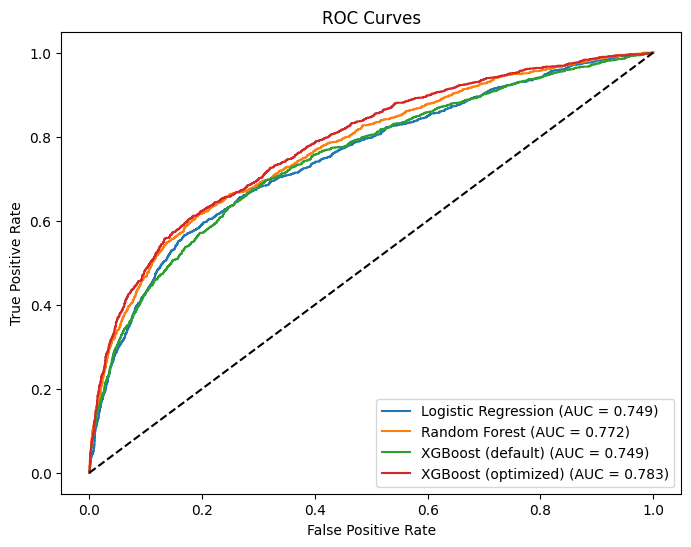

In [12]:
plt.figure(figsize=(8,6))
for name, (_, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Giải thích mô hình (Feature Importance)
## Feature importance từ Random Forest

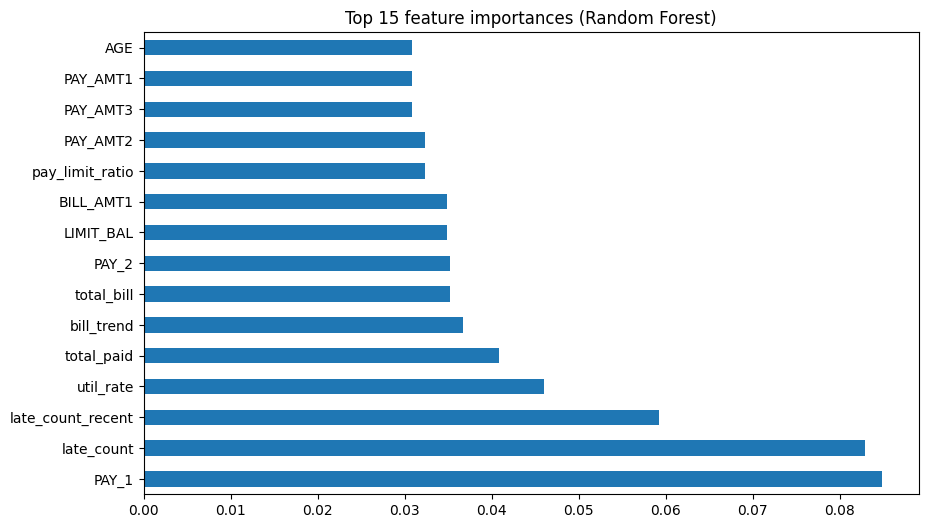

In [13]:
# Lấy tên đặc trưng sau khi preprocessor (khá phức tạp do có OHE)
# Cách đơn giản: lấy tất cả tên gốc và thêm các cột OHE
feature_names = scale_features.copy()
for cat in cat_features:
    unique_vals = df[cat].unique()
    for val in sorted(unique_vals)[1:]:  # bỏ giá trị đầu tiên (do drop='first')
        feature_names.append(f"{cat}_{val}")

importances = rf.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.title('Top 15 feature importances (Random Forest)')
plt.show()

## Feature importance từ XGBoost

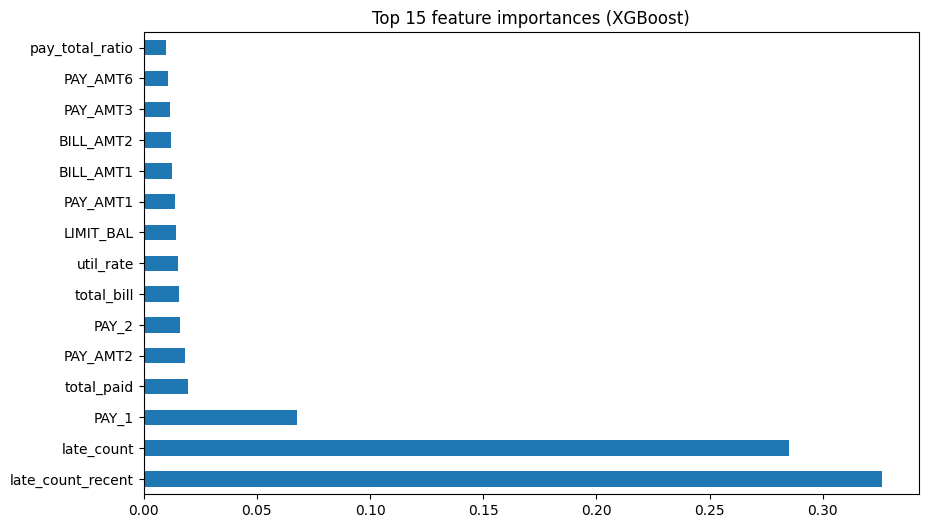

In [14]:
importances_xgb = best_xgb.named_steps['classifier'].feature_importances_
feat_imp_xgb = pd.Series(importances_xgb, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp_xgb.head(15).plot(kind='barh')
plt.title('Top 15 feature importances (XGBoost)')
plt.show()

# Lưu mô hình tốt nhất

In [17]:
import joblib
joblib.dump(best_xgb, '../models/credit_default_model.pkl')

['../models/credit_default_model.pkl']